In [1]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
sys.path.append("../")

import evaluate
import utils

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

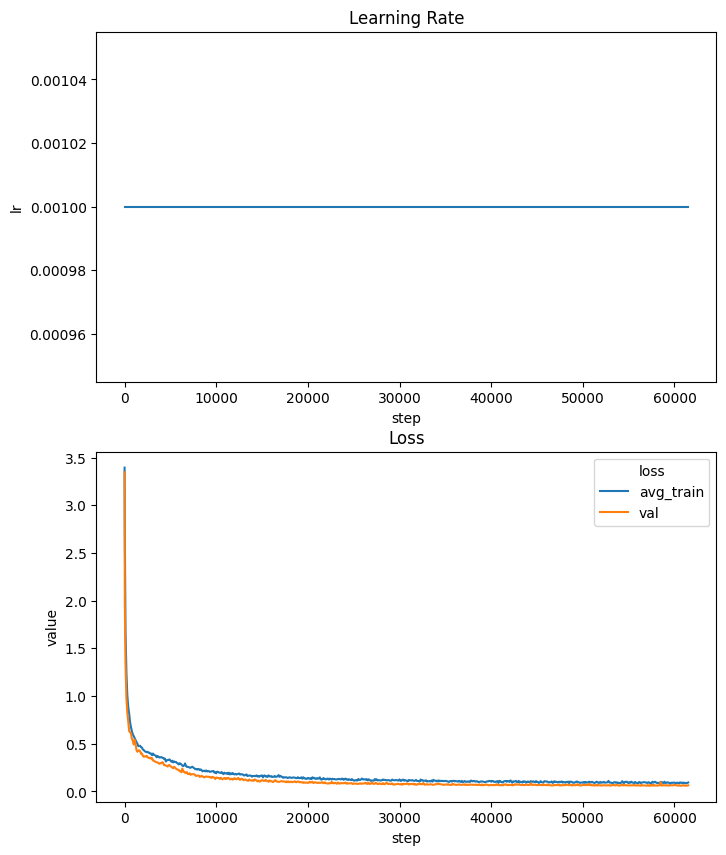

In [2]:
cp = utils.CheckPoint("../models/MLC_data200k_nepoch10.pt", device=DEVICE)
training_fig = cp.plot_training_data()

In [3]:
# load model & batch
net = cp.load_model()
train, val = cp.load_dataloaders(data_dir="../data")

 Loading model that has completed (or started) 10 of 10 epochs
  batch size: 25
  number of steps: 61540
  best val loss achieved: 0.0590
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


In [4]:
next(iter(val)).keys()

dict_keys(['xq_context', 'yq', 'xq_context_padded', 'xq_context_lengths', 'yq_padded', 'yq_lengths', 'yq_sos_padded', 'yq_sos_lengths', 'transformation', 'n_perm'])

In [ ]:
scores, trans_types = evaluate.evaluate_predictions(val, net, max_length=20, eval_type="max")


100%|██████████| 684/684 [08:07<00:00,  1.40it/s]


In [ ]:
accs = pd.DataFrame(columns=["correct", "permutation", "transformation", "out length"])

for batch in tqdm(val):
    preds = evaluate.predict(batch, net, val.dataset.langs, 20, eval_type="max")
    correct = [pred == true for pred, true in zip(preds,batch["yq"])]
    new_data = pd.DataFrame({
        "correct": correct,
        "permutation" : batch["n_perm"],
        "transformation" : batch["transformation"],
        "out length": batch["yq_lengths"]
        })
    accs = pd.concat([accs, new_data], ignore_index=True)

  0%|          | 0/684 [00:00<?, ?it/s]

100%|██████████| 684/684 [07:12<00:00,  1.58it/s]


In [5]:
print(f"Overall validation accuracy:{accs["correct"].mean():.3f}")

Overall validation accuracy:0.821


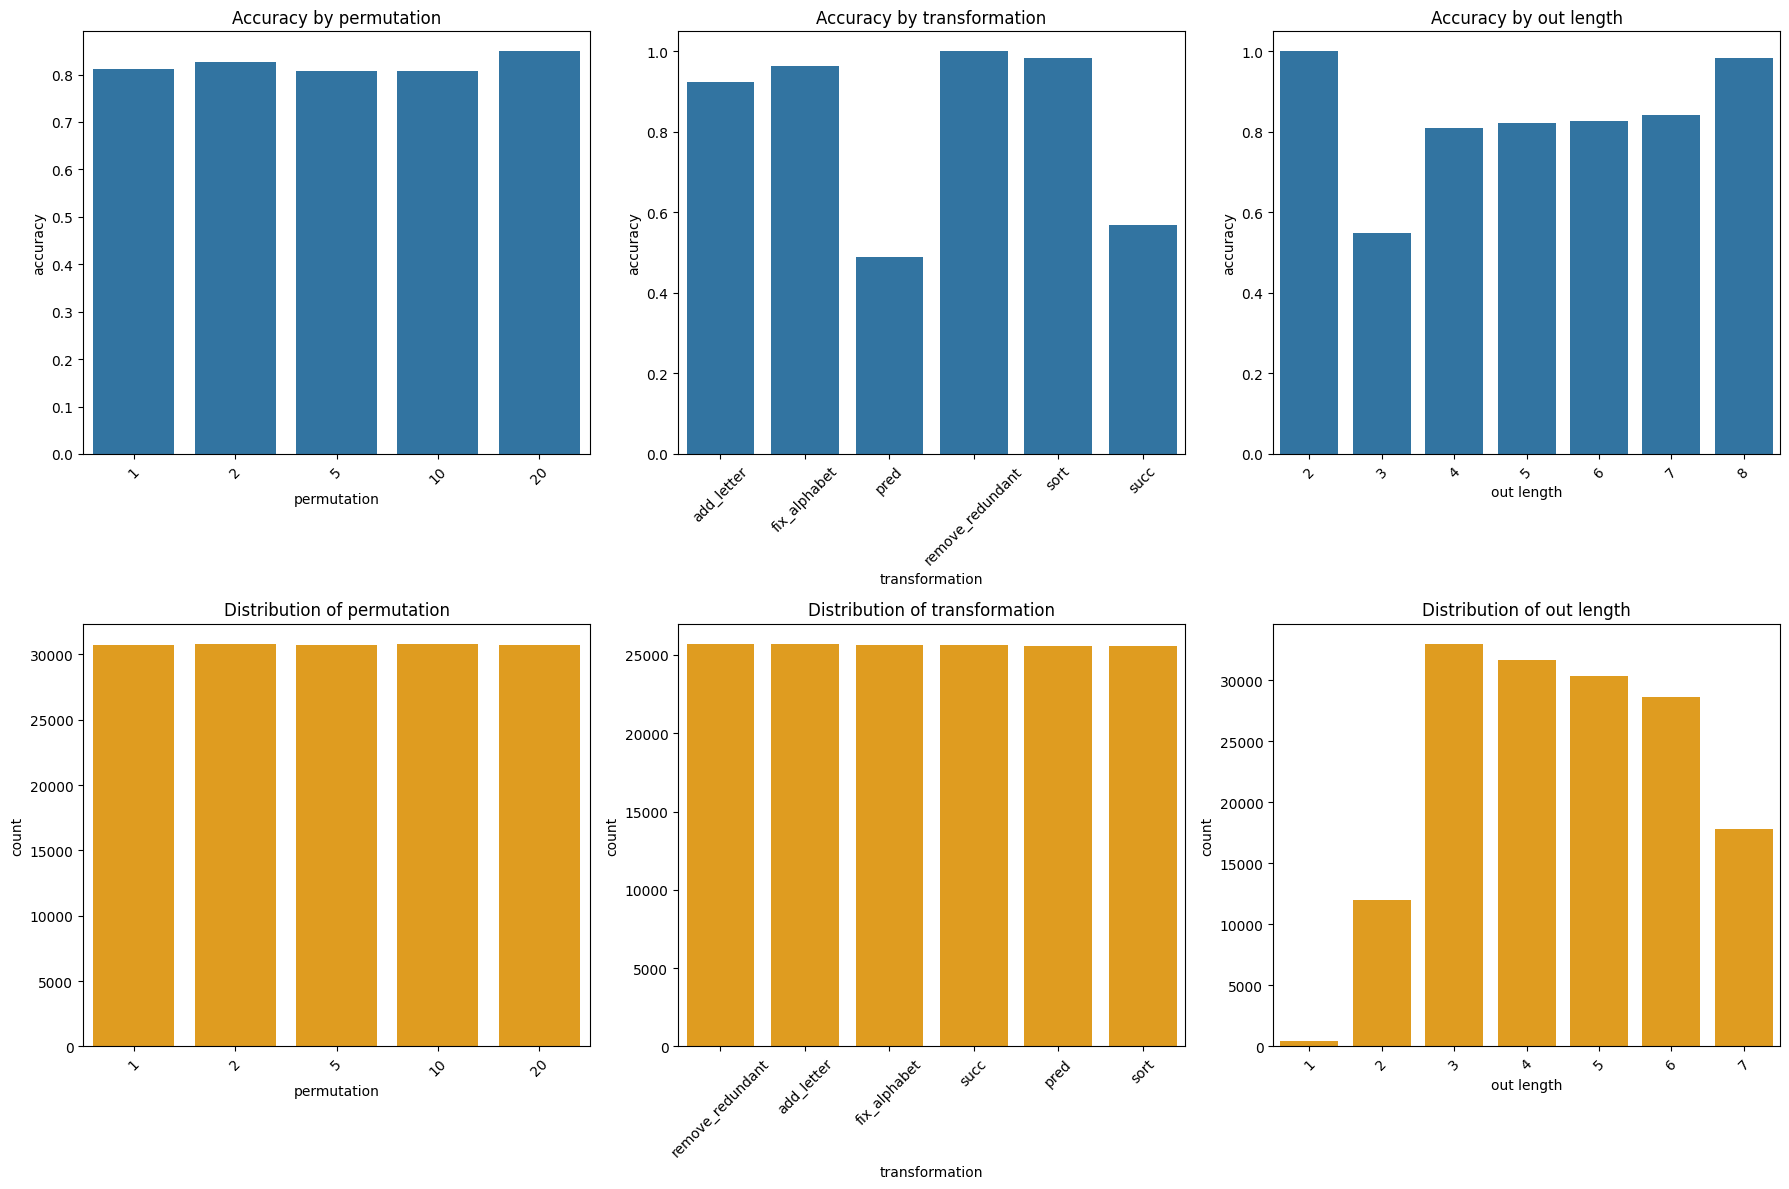

In [21]:
groupings = ["permutation", "transformation", "out length"]
train.dataset.data["out length"] = train.dataset.data["yq"].apply(lambda x: len(x))
train.dataset.data.rename(columns={"n_perm": "permutation"}, inplace=True)

fig, ax = plt.subplots(2, len(groupings), figsize=(6*len(groupings), 12))
for i, col in enumerate(groupings):
    grouped = pd.DataFrame(accs.groupby(col)["correct"].mean())
    grouped[col] = grouped.index
    sns.barplot(grouped, x=col, y="correct", ax=ax[0,i])
    ax[0,i].set_title(f"Accuracy by {col}")
    ax[0,i].set_ylabel("accuracy")
    ax[0,i].tick_params(axis='x', labelrotation=45)

    grouped = pd.DataFrame(train.dataset.data[col].value_counts())
    grouped[col] = grouped.index
    sns.barplot(grouped, x=col, y="count", ax=ax[1,i], color="orange")
    ax[1,i].set_title(f"Distribution of {col}")
    ax[1,i].set_ylabel("count")
    ax[1,i].tick_params(axis='x', labelrotation=45)

_ = fig.tight_layout()